In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Union

def read_json(in_file: Union[Path, str]):
    if not isinstance(in_file, Path):
        in_file = Path(in_file)
    return json.loads(in_file.read_text(encoding='utf8'))

In [4]:
METRIC_LIST = ['depth_ratio', 'ops_ratio', 'cx_ratio']


In [5]:
def get_ours_metrics(dir:  Path):
    if not isinstance(dir, Path):
        dir = Path(dir)
    assert dir.is_dir(), dir

    records = []
    for subdir in dir.iterdir():
        try:
            metrics = read_json(subdir / 'metrics.json')
            config = read_json(subdir / 'config.json')
        except:
            continue
        rec = {key.replace('metric/', ''): value for key, value in metrics.items()}
        rec.update(graph_name=config['hardware'].lower(),
                   circuit=config['circuit'],
                   layout_method=config['init_strategy'].lower() + '-ours',
                   opt_method='ours',
                   routing_method='ours',
                   opt_order='ours')
        records.append(rec)

    return pd.DataFrame.from_records(records)

df_ours = get_ours_metrics('./output/ours/nam_circs')

In [6]:
df_baseline = pd.read_csv('./output/baseline/nam_circs-star.csv')

In [7]:
len(df_ours.circuit.unique()), len(df_baseline.circuit.unique())

(21, 21)

In [8]:
df = pd.concat([df_ours, df_baseline], axis=0)
df = pd.melt(
    df,
    id_vars=[col for col in df.columns if col not in METRIC_LIST],
    value_vars=METRIC_LIST,
    var_name='metric',
    value_name='value'
)


In [9]:
def plot_bar_comparison(title, x):
    plt.figure(figsize=(15,3))
    plt.suptitle(title)

    for i, metric in enumerate(METRIC_LIST):
        ax = plt.subplot(1,len(METRIC_LIST),i+1)
        sns.barplot(df[df.metric == metric], hue='metric', y='value', x=x, ax=ax, legend=False)
        plt.ylabel(metric)
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

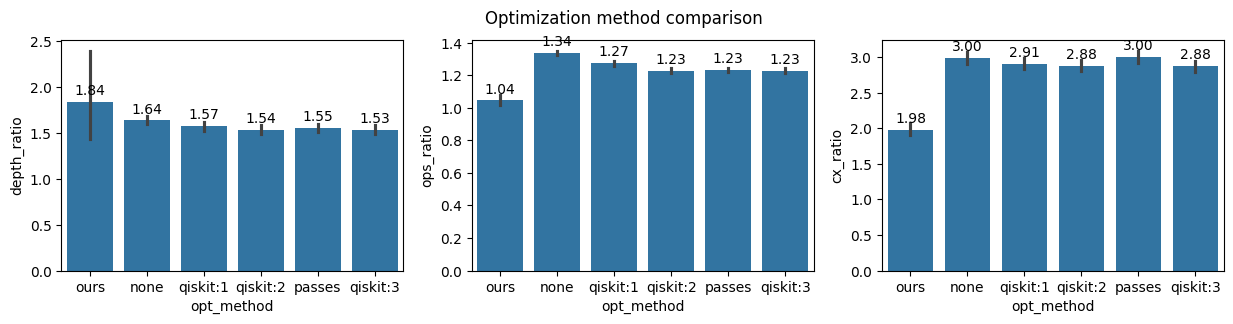

In [10]:
plot_bar_comparison(title='Optimization method comparison', x='opt_method')

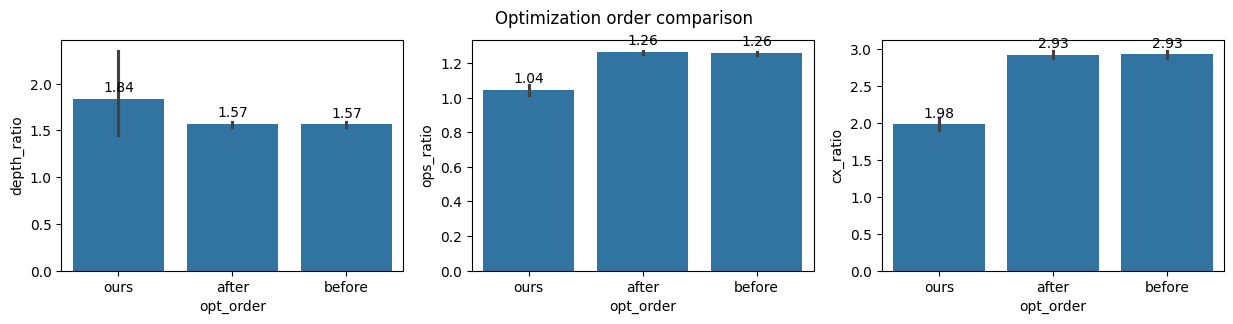

In [11]:
plot_bar_comparison(title='Optimization order comparison', x='opt_order')


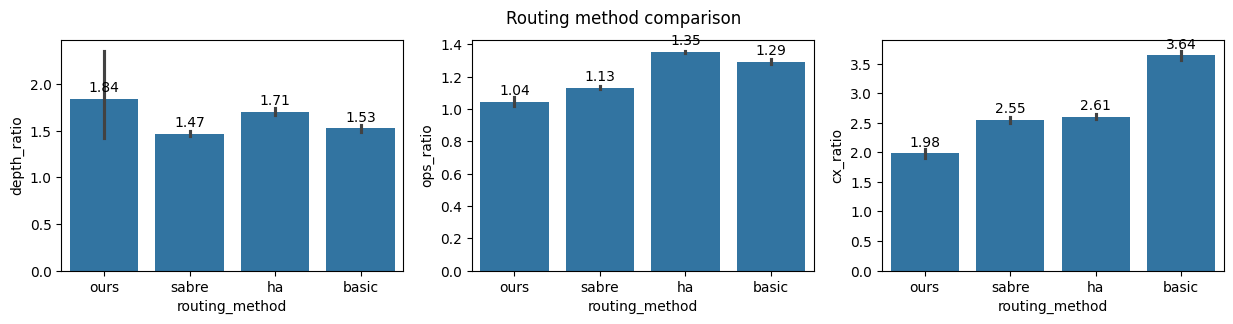

In [12]:
plot_bar_comparison(title='Routing method comparison', x='routing_method')


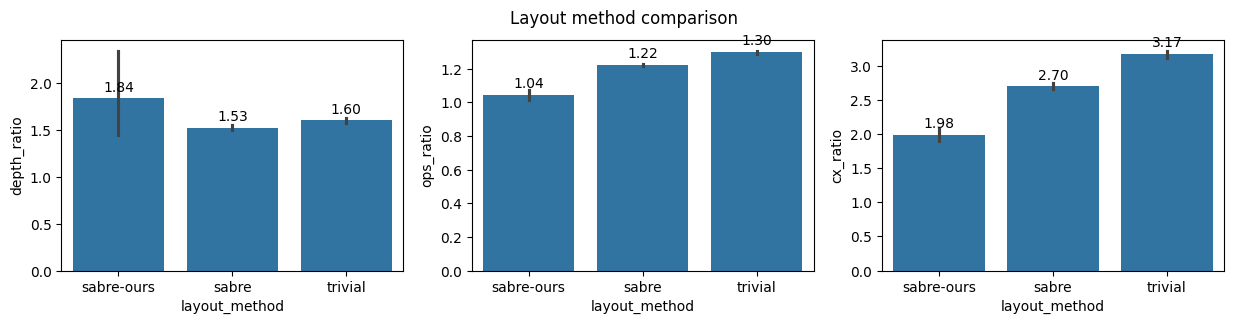

In [13]:
plot_bar_comparison(title='Layout method comparison', x='layout_method')